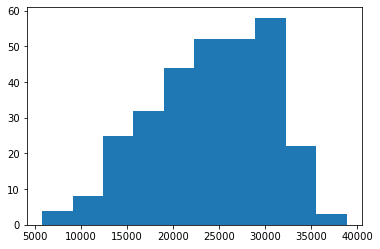

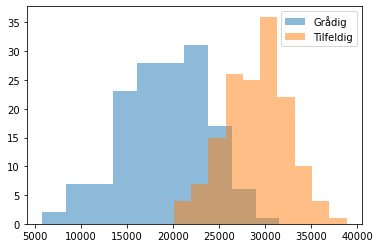

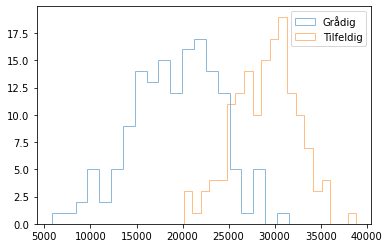

In [22]:
import random
import matplotlib.pyplot as plt

fiske_data = {"kapasitet": 75, "skuter_antall": 3, "kost_per_kg": 5}
skuteID = 0

def fisk_graadig():
    return fiske_data["kapasitet"]

def fisk_tilfeldig():
    return fiske_data["kapasitet"]*random.random()
    
def lag_gradig_skute():
    global skuteID
    skute = {"navn": "Grådig",
             "id": skuteID,
             "fiskefunksjon": fisk_graadig, 
             "tidligere_kvantum": [], 
             "saldo": 1000}
    skuteID += 1
    return skute

def lag_tilfeldig_skute():
    global skuteID
    skute = {"navn": "Tilfeldig",
             "id": skuteID,
             "fiskefunksjon": fisk_tilfeldig, 
             "tidligere_kvantum": [], 
             "saldo": 1000}
    skuteID += 1
    return skute

def beregn_markedspris(Q1, Q2, Q3):
    return 45-0.2*(Q1+Q2+Q3)

def beregn_profitt(P, Q):
    return Q*(P-fiske_data["kost_per_kg"])

def fisk_reker(reke_skuter):
    for skute in reke_skuter:
        fiskefunksjon = skute["fiskefunksjon"]
        skute["fangst"] = fiskefunksjon()
  
def selg_reker(reke_skuter):
    Q1, Q2, Q3 = (skute["fangst"] for skute in reke_skuter)
    Pris = beregn_markedspris(Q1, Q2, Q3)
    for skute in reke_skuter:
        skute["saldo"] += beregn_profitt(Pris, skute["fangst"])


def simuler_fiske(reke_flaate):
    antall_skuter = len(reke_flaate)
    random.shuffle(reke_flaate)
    for i in range(0,antall_skuter,3):
        fisk_reker(reke_flaate[i:i+3])
        selg_reker(reke_flaate[i:i+3])

fiske_flaate = [lag_tilfeldig_skute() for i in range(150)] + [lag_gradig_skute() for i in range(150)]
for i in range(100):
    simuler_fiske(fiske_flaate)
    
saldo = [skute["saldo"] for skute in fiske_flaate]
saldo_graadig = [skute["saldo"] for skute in fiske_flaate if skute["navn"] == "Grådig"]
saldo_tilfeldig = [skute["saldo"] for skute in fiske_flaate if skute["navn"] == "Tilfeldig"]
plt.hist(saldo)
plt.show()

plt.hist(saldo_graadig, label="Grådig", alpha=0.5)
plt.hist(saldo_tilfeldig, label="Tilfeldig", alpha=0.5)
plt.legend()
plt.show()

plt.hist(saldo_graadig, label="Grådig", alpha=0.5, histtype="step", bins=20)
plt.hist(saldo_tilfeldig, label="Tilfeldig", alpha=0.5, histtype="step", bins=20)
plt.legend()
plt.show()
        

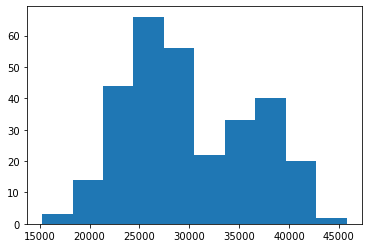

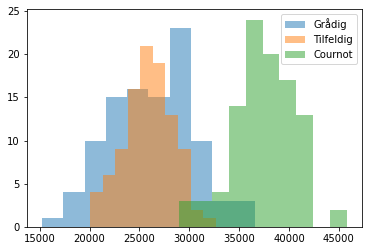

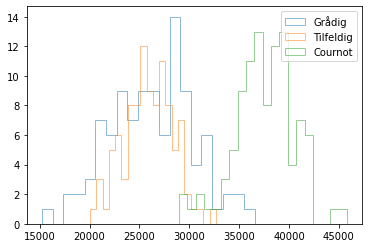

In [40]:
import random
import matplotlib.pyplot as plt
from scipy.optimize import minimize_scalar

fiske_data = {"kapasitet": 75, "skuter_antall": 3, "kost_per_kg": 5}
skuteID = 0

def fisk_graadig(skuter=None):
    return fiske_data["kapasitet"]

def fisk_tilfeldig(skuter=None):
    return fiske_data["kapasitet"]*random.random()


    
    
def lag_gradig_skute():
    global skuteID
    skute = {"navn": "Grådig",
             "id": skuteID,
             "fiskefunksjon": fisk_graadig, 
             "tidligere_kvantum": [], 
             "saldo": 1000}
    skuteID += 1
    return skute

def lag_tilfeldig_skute():
    global skuteID
    skute = {"navn": "Tilfeldig",
             "id": skuteID,
             "fiskefunksjon": fisk_tilfeldig, 
             "tidligere_kvantum": [], 
             "saldo": 1000}
    skuteID += 1
    return skute

def beregn_best_kvantum(Q1,Q2):
    def fun(Q):
        return -Q*beregn_markedspris(Q1,Q2,Q)
    Q = minimize_scalar(fun)
    return min(75,Q.x)


def fisk_Cournot(skuter, minSkuteID):
    konkurrerende_skuter = [skute for skute in skuter if skute["id"] != minSkuteID]
    Q = []
    for skute in konkurrerende_skuter:
        tidligere = skute["tidligere_kvantum"]
        if tidligere == []:
            Q.append(75)
        else:
            Q.append(sum(tidligere)/len(tidligere))
    Q_max = beregn_best_kvantum(Q[0], Q[1])
    return Q_max

def lag_Cournot_skute():
    global skuteID
    
    skute = {"navn": "Cournot",
             "id": skuteID,
             "fiskefunksjon": lambda s: fisk_Cournot(s, skuteID), 
             "tidligere_kvantum": [], 
             "saldo": 1000}
    skuteID += 1
    return skute

    
def beregn_markedspris(Q1, Q2, Q3):
    return 45-0.2*(Q1+Q2+Q3)

def beregn_profitt(P, Q):
    return Q*(P-fiske_data["kost_per_kg"])

def fisk_reker(reke_skuter):
    for skute in reke_skuter:
        fiskefunksjon = skute["fiskefunksjon"]
        skute["fangst"] = fiskefunksjon(reke_skuter)
        skute["tidligere_kvantum"].append(skute["fangst"])
  
def selg_reker(reke_skuter):
    Q1, Q2, Q3 = (skute["fangst"] for skute in reke_skuter)
    Pris = beregn_markedspris(Q1, Q2, Q3)
    for skute in reke_skuter:
        skute["saldo"] += beregn_profitt(Pris, skute["fangst"])


def simuler_fiske(reke_flaate):
    antall_skuter = len(reke_flaate)
    random.shuffle(reke_flaate)
    for i in range(0,antall_skuter,3):
        fisk_reker(reke_flaate[i:i+3])
        selg_reker(reke_flaate[i:i+3])






fiske_flaate = [lag_tilfeldig_skute() for i in range(100)] 
fiske_flaate.extend([lag_gradig_skute() for i in range(100)])
fiske_flaate.extend([lag_Cournot_skute() for i in range(100)])

for i in range(100):
    simuler_fiske(fiske_flaate)
    
saldo = [skute["saldo"] for skute in fiske_flaate]
saldo_graadig = [skute["saldo"] for skute in fiske_flaate if skute["navn"] == "Grådig"]
saldo_tilfeldig = [skute["saldo"] for skute in fiske_flaate if skute["navn"] == "Tilfeldig"]
saldo_cournot = [skute["saldo"] for skute in fiske_flaate if skute["navn"] == "Cournot"]
plt.hist(saldo)
plt.show()

plt.hist(saldo_graadig, label="Grådig", alpha=0.5)
plt.hist(saldo_tilfeldig, label="Tilfeldig", alpha=0.5)
plt.hist(saldo_cournot, label="Cournot", alpha=0.5)
plt.legend()
plt.show()

plt.hist(saldo_graadig, label="Grådig", alpha=0.5, histtype="step", bins=20)
plt.hist(saldo_tilfeldig, label="Tilfeldig", alpha=0.5, histtype="step", bins=20)
plt.hist(saldo_cournot, label="Cournot", alpha=0.5, histtype="step", bins=20)
plt.legend()
plt.show()
        